In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import tukeylambda
import os


In [9]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()


# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
addie_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
addie_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(addie_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(addie_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
addie_in_tune_df.to_csv(in_tune_csv_path, index=False)
addie_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Addie
In-tune correct: 110 / 138 (79.71%)
Out-of-tune correct: 107 / 138 (77.54%)
Correct responses: 217
Incorrect responses: 59
Overall accuracy: 78.62%
In-Tune Average RT DataFrame:
    Gap  AddieInAveRT
0    50    491.000000
1    60    455.000000
2    70    416.000000
3    80    522.000000
4    90    472.500000
5   100    453.500000
6   110    592.000000
7   120    466.000000
8   130    491.500000
9   140    624.500000
10  150    384.500000
11  160    382.500000
12  170    460.000000
13  180    708.500000
14  190    539.250000
15  200    370.000000
16  210    454.000000
17  220    473.000000
18  230    568.000000
19  240    524.666667
20  250    664.000000
21  260    487.500000
22  270    623.000000
23  280    520.000000
24  290    538.000000
25  300    556.000000
26  310    587.000000
27  320    662.666667
28  330    583.666667
29  340    436.000000
30  350    700.000000
31  360    488.000000
32  370    595.000000
33  380    585.000000
34  390    477.000000
35  400    

In [10]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
angelyn_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
angelyn_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
angelyn_in_tune_df.to_csv(in_tune_csv_path, index=False)
angelyn_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Angelyn
In-tune correct: 129 / 138 (93.48%)
Out-of-tune correct: 130 / 138 (94.20%)
Correct responses: 259
Incorrect responses: 17
Overall accuracy: 93.84%
In-tune data saved to angelyn_in_tune_avg_rt.csv
Out-of-tune data saved to angelyn_out_of_tune_avg_rt.csv


In [17]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/lila/Lila1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/lila/Lila1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/lila/Lila1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
lila_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
lila_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(lila_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(lila_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
lila_in_tune_df.to_csv(in_tune_csv_path, index=False)
lila_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Lila
In-tune correct: 131 / 138 (94.93%)
Out-of-tune correct: 120 / 138 (86.96%)
Correct responses: 251
Incorrect responses: 25
Overall accuracy: 90.94%
In-Tune Average RT DataFrame:
    Gap  LilaInAveRT
0    50   404.666667
1    60   521.000000
2    70   524.000000
3    80   524.500000
4    90   378.000000
5   100   432.000000
6   110   485.000000
7   120   409.333333
8   130   418.000000
9   140   391.500000
10  150   482.666667
11  160   414.666667
12  170   438.000000
13  180   518.333333
14  190   490.500000
15  200   547.666667
16  210   491.666667
17  220   466.666667
18  230   447.000000
19  240   380.666667
20  250   367.333333
21  260   399.500000
22  270   496.333333
23  280   420.666667
24  290   403.333333
25  300   393.666667
26  310   392.000000
27  320   391.333333
28  330   462.000000
29  340   383.000000
30  350   453.333333
31  360   553.666667
32  370   443.666667
33  380   423.333333
34  390   400.666667
35  400   452.333333
36  410   440.000000
37  42

In [18]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
mahalakshmi_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
mahalakshmi_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(mahalakshmi_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(mahalakshmi_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
mahalakshmi_in_tune_df.to_csv(in_tune_csv_path, index=False)
mahalakshmi_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Mahalakshmi
In-tune correct: 133 / 138 (96.38%)
Out-of-tune correct: 131 / 138 (94.93%)
Correct responses: 264
Incorrect responses: 12
Overall accuracy: 95.65%
In-Tune Average RT DataFrame:
    Gap  MahalakshmiInAveRT
0    50          774.000000
1    60          542.333333
2    70          729.000000
3    80          770.000000
4    90          612.500000
5   100          536.500000
6   110          653.000000
7   120          672.500000
8   130          575.000000
9   140          657.666667
10  150          813.000000
11  160          731.000000
12  170          666.000000
13  180          741.666667
14  190          732.000000
15  200          662.333333
16  210          594.500000
17  220          673.666667
18  230          641.000000
19  240          653.000000
20  250          638.333333
21  260          514.000000
22  270          638.500000
23  280          562.000000
24  290          712.000000
25  300          825.000000
26  310          670.000000
27  320      

In [25]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.3.csv",
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method="linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
manaswini_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
manaswini_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(manaswini_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(manaswini_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
manaswini_in_tune_df.to_csv(in_tune_csv_path, index=False)
manaswini_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Manaswini
In-tune correct: 97 / 138 (70.29%)
Out-of-tune correct: 81 / 138 (58.70%)
Correct responses: 178
Incorrect responses: 98
Overall accuracy: 64.49%
In-Tune Average RT DataFrame:
    Gap  ManaswiniInAveRT
0    50        793.000000
1    60        952.666667
2    70        998.500000
3    80        905.000000
4    90        996.000000
5   110        932.500000
6   120        870.500000
7   140        951.000000
8   150        905.333333
9   160        859.666667
10  170        814.000000
11  180        889.000000
12  190        838.000000
13  220        924.000000
14  230        805.000000
15  240        852.000000
16  250        899.000000
17  260        920.000000
18  270        907.500000
19  280        875.000000
20  290        875.000000
21  310        875.000000
22  320        875.000000
23  330        875.000000
24  340        991.000000
25  350        836.000000
26  370        845.250000
27  380        854.500000
28  390        863.750000
29  400        873.00

In [20]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/navya/Navya1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/navya/Navya1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/navya/Navya1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
navya_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
navya_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(navya_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(navya_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
navya_in_tune_df.to_csv(in_tune_csv_path, index=False)
navya_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Navya
In-tune correct: 99 / 138 (71.74%)
Out-of-tune correct: 79 / 138 (57.25%)
Correct responses: 178
Incorrect responses: 98
Overall accuracy: 64.49%
In-Tune Average RT DataFrame:
    Gap  NavyaInAveRT
0    50    595.000000
1    60    724.000000
2    70    843.000000
3    80    630.333333
4    90    519.000000
5   100    534.333333
6   110    686.000000
7   120    689.333333
8   130    496.000000
9   140    558.000000
10  150    529.000000
11  160    556.000000
12  170    492.333333
13  180    507.000000
14  190    609.500000
15  200    423.000000
16  210    676.500000
17  220    598.500000
18  230    497.500000
19  240    561.666667
20  250    806.000000
21  260    524.500000
22  270    598.500000
23  280    627.500000
24  290    656.500000
25  300    506.500000
26  310    614.750000
27  320    723.000000
28  330    694.000000
29  340    571.000000
30  350    481.000000
31  360    704.500000
32  370    570.000000
33  380    532.500000
34  390    443.000000
35  400    64

In [21]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/richard/richard 1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/richard/richard 1.3.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/richard/richard1.1.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
richard_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
richard_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(richard_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(richard_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
richard_in_tune_df.to_csv(in_tune_csv_path, index=False)
richard_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Richard
In-tune correct: 132 / 138 (95.65%)
Out-of-tune correct: 125 / 138 (90.58%)
Correct responses: 257
Incorrect responses: 19
Overall accuracy: 93.12%
In-Tune Average RT DataFrame:
    Gap  RichardInAveRT
0    50      521.000000
1    60      490.000000
2    70      522.000000
3    80      481.333333
4    90      559.000000
5   100      464.000000
6   110      493.000000
7   120      547.666667
8   130      515.666667
9   140      539.333333
10  150      612.000000
11  160      489.000000
12  170      522.666667
13  180      535.000000
14  190      511.000000
15  200      526.333333
16  210      540.666667
17  220      518.666667
18  230      473.333333
19  240      494.333333
20  250      493.333333
21  260      524.666667
22  270      512.333333
23  280      502.333333
24  290      480.000000
25  300      485.333333
26  310      508.000000
27  320      521.000000
28  330      427.000000
29  340      454.500000
30  350      492.666667
31  360      535.000000
32  370  

In [22]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Sree/sree 1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Sree/sree 1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Sree/sree 1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

# Remove outliers
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

# Sort in ascending order by Gap
df = df.sort_values(by='Gap').copy()

from scipy.stats import pearsonr

Ave = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
Ave[f'{participant_name}InAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
Ave[f'{participant_name}OutAveRT'] = Ave['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

Ave[f"{participant_name}InAveRT"] = Ave[f"{participant_name}InAveRT"].interpolate(method = "linear").ffill().bfill()
Ave[f"{participant_name}OutAveRT"] = Ave[f"{participant_name}OutAveRT"].interpolate(method = "linear").ffill().bfill()

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
sree_in_tune_df = pd.DataFrame({'Gap': Ave['Gap'], f'{participant_name}InAveRT': Ave[f'{participant_name}InAveRT']})
sree_out_of_tune_df = pd.DataFrame({'Gap': Ave['Gap'], 'OutAveRT': Ave[f'{participant_name}OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(sree_in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(sree_out_of_tune_df)

in_tune_csv_path = f"{participant_name.lower()}_in_tune_avg_rt.csv"
out_of_tune_csv_path = f"{participant_name.lower()}_out_of_tune_avg_rt.csv"
sree_in_tune_df.to_csv(in_tune_csv_path, index=False)
sree_out_of_tune_df.to_csv(out_of_tune_csv_path, index=False)

print(f"In-tune data saved to {in_tune_csv_path}")
print(f"Out-of-tune data saved to {out_of_tune_csv_path}")


Participant: Sree
In-tune correct: 126 / 138 (91.30%)
Out-of-tune correct: 133 / 138 (96.38%)
Correct responses: 259
Incorrect responses: 17
Overall accuracy: 93.84%
In-Tune Average RT DataFrame:
    Gap  SreeInAveRT
0    50   535.000000
1    60   538.333333
2    70   558.333333
3    80   510.333333
4    90   541.333333
5   100   449.333333
6   110   623.500000
7   120   632.000000
8   130   571.333333
9   140   527.000000
10  150   502.666667
11  160   605.333333
12  170   519.000000
13  180   474.333333
14  190   441.000000
15  200   536.000000
16  210   504.000000
17  220   573.000000
18  230   565.333333
19  240   598.000000
20  250   523.000000
21  260   658.500000
22  270   622.000000
23  280   513.000000
24  290   435.333333
25  300   598.666667
26  310   554.333333
27  320   463.000000
28  330   495.000000
29  340   657.333333
30  350   583.333333
31  360   533.333333
32  370   542.500000
33  380   532.500000
34  390   492.000000
35  400   561.333333
36  410   460.500000
37  42

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

angelyn_rt = angelyn_in_tune_df['AngelynInAveRT'].values.reshape(1, -1)
addie_rt = addie_in_tune_df['AddieInAveRT'].values.reshape(1, -1)

print(angelyn_rt, addie_rt)

similarity = cosine_similarity(angelyn_rt, addie_rt)[0][0]

print("Cosine Similarity:", similarity)


[[408.33333333 432.66666667 375.33333333 467.33333333 355.
  363.33333333 430.33333333 434.         332.         383.
  403.66666667 392.         419.33333333 388.5        327.
  403.         453.33333333 371.66666667 404.33333333 381.66666667
  349.33333333 343.33333333 307.         371.         353.66666667
  397.66666667 375.         336.33333333 388.33333333 328.
  381.         462.66666667 336.5        391.66666667 315.5
  364.         488.33333333 371.33333333 401.33333333 457.33333333
  363.66666667 282.         385.66666667 394.33333333 370.66666667
  348.        ]] [[491.         455.         416.         522.         472.5
  453.5        592.         466.         491.5        624.5
  384.5        382.5        460.         708.5        539.25
  370.         454.         473.         568.         524.66666667
  664.         487.5        623.         520.         538.
  556.         587.         662.66666667 583.66666667 436.
  700.         488.         595.         585.        

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# List of in-tune DataFrames and corresponding participant names
participant_dfs = {
    "Angelyn": angelyn_in_tune_df,
    "Addie": addie_in_tune_df,
    "Lila": lila_in_tune_df,
    "Mahalakshmi": mahalakshmi_in_tune_df,
    "Navya": navya_in_tune_df,
    "Richard": richard_in_tune_df,
    "Sree": sree_in_tune_df
}

# Create a matrix where each row is a participant's in-tune average RTs
rt_matrix = []
participant_names = []

for name, df in participant_dfs.items():
    col_name = f"{name}InAveRT"
    rt_values = df[col_name].values
    rt_matrix.append(rt_values)
    participant_names.append(name)

# Convert to numpy array
rt_matrix = np.array(rt_matrix)

# Compute cosine similarity matrix
similarity_matrix = 1 - cosine_similarity(rt_matrix)

# Create a DataFrame for nicer display
similarity_df = pd.DataFrame(similarity_matrix, index=participant_names, columns=participant_names)

print("Cosine Similarity Matrix (In-Tune Average RTs):")
print(similarity_df.round(4))  # Rounded for clarity


Cosine Similarity Matrix (In-Tune Average RTs):
             Angelyn   Addie    Lila  Mahalakshmi   Navya  Richard    Sree
Angelyn       0.0000  0.0241  0.0091       0.0114  0.0179   0.0132  0.0124
Addie         0.0241  0.0000  0.0224       0.0225  0.0243   0.0210  0.0211
Lila          0.0091  0.0224  0.0000       0.0145  0.0166   0.0124  0.0147
Mahalakshmi   0.0114  0.0225  0.0145      -0.0000  0.0246   0.0155  0.0137
Navya         0.0179  0.0243  0.0166       0.0246  0.0000   0.0196  0.0206
Richard       0.0132  0.0210  0.0124       0.0155  0.0196   0.0000  0.0111
Sree          0.0124  0.0211  0.0147       0.0137  0.0206   0.0111 -0.0000


In [34]:
from sklearn.manifold import MDS 

embedding = MDS (n_components=2, metric= False, n_init=2, max_iter=100, 
                 verbose=0, eps=0.001, n_jobs=2, random_state=101, 
                ,dissimilarity='euclidean')
#precip=precip[0:100]

similarity_df = embedding.fit_transform(similarity_df)
similarity_df

SyntaxError: invalid syntax (2166595220.py, line 5)

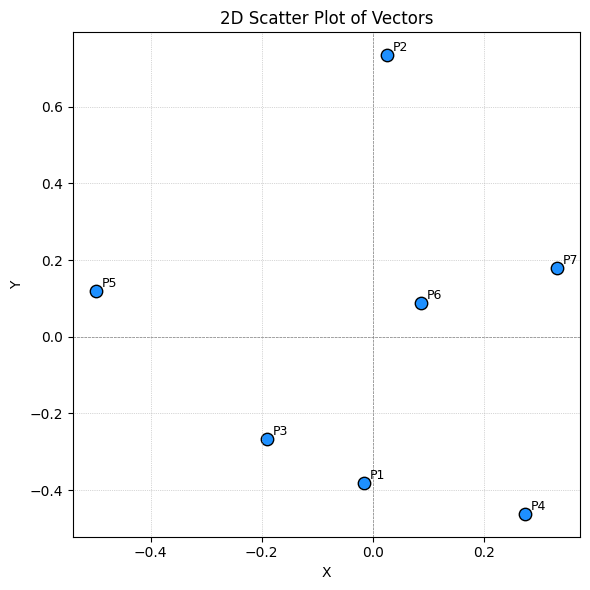

In [ ]:
import matplotlib.pyplot as plt

# Coordinates
points = [
    [-0.01492294, -0.38194023],
    [ 0.02620121,  0.73389997],
    [-0.19038764, -0.2665932 ],
    [ 0.27492871, -0.46151489],
    [-0.49882925,  0.11971741],
    [ 0.08786149,  0.08890669],
    [ 0.33206932,  0.17859846]
]

x_vals = [x for x, y in points]
y_vals = [y for x, y in points]


plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals, color='dodgerblue', edgecolor='black', s=80)
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.grid(True, linestyle=':', linewidth=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Scatter Plot of Vectors")
for i, (x, y) in enumerate(points):
    plt.text(x + 0.01, y + 0.01, f"P{i+1}", fontsize=9)

plt.tight_layout()
plt.show()


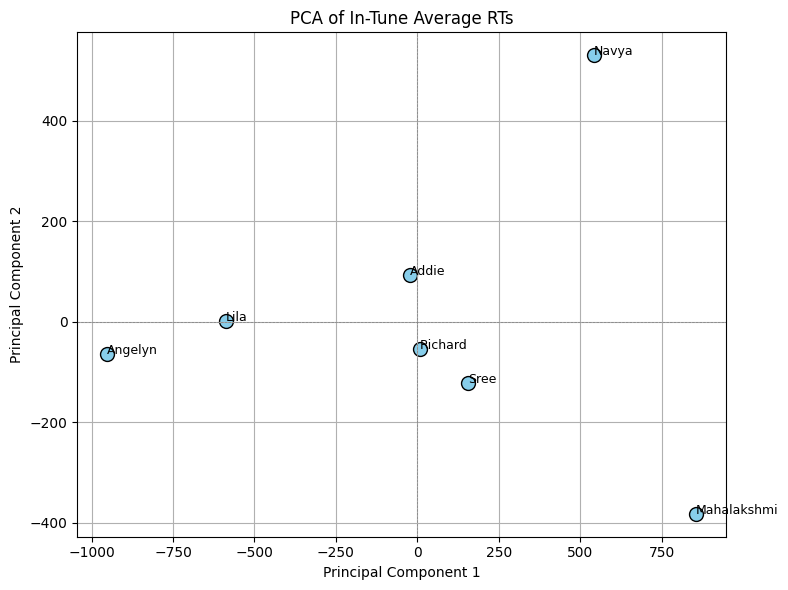

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA on the original RT feature matrix
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(rt_matrix)

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Participant'] = participant_names

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, color='skyblue', edgecolor='black')

# Annotate each point
for i, row in pca_df.iterrows():
    plt.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['Participant'], fontsize=9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('PCA of In-Tune Average RTs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

cosine_distances = cosine_similarity(rt_matrix)

# Create labeled DataFrame
similarity_df = pd.DataFrame(cosine_distances, index=participant_names, columns=participant_names)

# Extract only the values (distance matrix)
distance_matrix = similarity_df.values

# Fit Agglomerative Clustering
model = AgglomerativeClustering(
    linkage='average',
    n_clusters=3
)
cluster_labels = model.fit_predict(distance_matrix)

# Add cluster labels to a *copy* of the similarity_df
result_df = similarity_df.copy()
result_df['Cluster'] = cluster_labels
print(result_df[['Cluster']])


             Cluster
Angelyn            0
Addie              1
Lila               0
Mahalakshmi        0
Navya              2
Richard            0
Sree               0
